# Classwork Assignment 08: Training Linear Models - Part 2

**Course:** Data Analytics and Machine Learning - Spring 2026 - Created by Golnaz Sahebi 

**Topics:** Polynomial Regression, Regularization, and Logistic Regression

### **Objective**

In this lab, you will explore how to:
1. Handle non-linear relationships using **Polynomial Features**.
2. Apply **Regularization** to prevent overfitting in complex models.
3. Transition from regression to classification using **Logistic Regression** for medical diagnosis.

---

  
## Task 1: Polynomial Regression & Regularization (45 Minutes)
**Dataset:** `load_diabetes()`

1. **Pre-processing:** Load the dataset, split it (80/20), and standardize the features using `StandardScaler`.
2. **Polynomialization:** Apply `PolynomialFeatures` with **degree=2** to your scaled training and test data.
3. **Model Training:** Train **Ridge**, **Lasso**, and **ElasticNet** models on the polynomial features using `alpha=0.1`.
4. **Evaluation:** Calculate the **Mean Squared Error (MSE)** for all three and compare them.

**Questions:**
* How many features does the dataset have after applying degree-2 polynomial features?
* Which regularization method handled the increased complexity best?
  
  **Note:** In machine learning, the best model is the one with the lowest error on the test set.

In [3]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error

# 1. Load and Split

data = load_diabetes()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

print(X_train.shape, X_test.shape)

(353, 10) (89, 10)


In [4]:
df = pd.DataFrame(X, columns = data.feature_names)
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [5]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01


In [6]:
# 2. Scale and Polynomialize

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

poly = PolynomialFeatures(degree = 2, include_bias = False)

X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

print("Original shape:", X_train.shape)
print("After polynomial:", X_train_poly.shape)

Original shape: (353, 10)
After polynomial: (353, 65)


In [7]:
# 3. Cross-Validation

alpha_val = 0.1
models = {
    "Ridge": Ridge(alpha = alpha_val),
    "Lasso": Lasso(alpha = alpha_val, max_iter = 10000), # Note: max_iter added to prevent convergence warnings
    "ElasticNet": ElasticNet(alpha = alpha_val, l1_ratio = 0.5, max_iter = 10000)
}

print("--- 5-Fold Cross-Validation (Mean MSE) ---")

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train_poly,
        y_train,
        cv = 5,
        scoring = "neg_mean_squared_error"
    )
    
    mean_mse = -scores.mean()
    print(f"{name}: {mean_mse:.2f}")

# 4. Final Evaluation

print("\n--- Final Test Set Performance ---")

for name, model in models.items():
    model.fit(X_train_poly, y_train)
    y_pred = model.predict(X_test_poly)
    mse = mean_squared_error(y_test, y_pred)
    print(f"{name}: {mse:.2f}")

--- 5-Fold Cross-Validation (Mean MSE) ---
Ridge: 3974.26
Lasso: 3712.18
ElasticNet: 3501.79

--- Final Test Set Performance ---
Ridge: 3070.57
Lasso: 2779.66
ElasticNet: 2599.43


**Answer to the questions:** 

How many features does the dataset have after applying degree-2 polynomial features?

Original shape: (353, 10)
After polynomial: (353, 65)

So it has 65 features.

Which regularization method handled the increased complexity best?

The ElasticNet one as it achieved the lowest MSE on both cross validation: Ridge: 3974.26, Lasso: 3712.18, ElasticNet: 3501.79 and Final test: Ridge: 3070.57, Lasso: 2779.66, ElasticNet: 2599.43.

---

## Task 2: Logistic Regression for Medical Diagnosis (35 Minutes)
**Dataset:** `load_breast_cancer()`

**Goal:** Predict if a tumor is **Malignant (0)** or **Benign (1)** based on its **Mean Radius**.

1. **Setup:** Load the data and select only the first column (**mean radius**) as your feature `X`.
2. **Train:** Split the data (80/20) and train a `LogisticRegression` model.
3. **Visualize the Probability:**
    * Generate 1000 points between 0 and 30mm using `np.linspace`.
    * Predict the probabilities using `predict_proba()`.
5. **Identify Decision Boundary:** Find the radius value where the probability of being Benign is exactly 50%.
6. **Predict:** If a patient's tumor has a radius of **15.5mm**, what is the model's prediction? Use `predict()` and `predict_proba()`.

In [8]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

# 1. Setup

data2 = load_breast_cancer()
X2 = data2.data[:, 0].reshape(-1, 1)
y2 = data2.target

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size = 0.2, random_state = 42)

In [9]:
# 2. Train Model

model2 = LogisticRegression()

model2.fit(X_train2, y_train2)

LogisticRegression()

In [10]:
# 3. Decision Boundary

X_new = np.linspace(0, 30, 1000).reshape(-1, 1)

y_proba = model2.predict_proba(X_new)
y_proba_benign = y_proba[:, 1]

idx = np.argmin(np.abs(y_proba_benign - 0.5))
decision_boundary = X_new[idx]

print("Decision boundary (radius):", decision_boundary[0])

Decision boundary (radius): 14.804804804804805


In [11]:
# 4. Predict

X_sample = np.array([[15.5]])

proba = model2.predict_proba(X_sample)

print("Probability [malignant, benign]:", proba[0])
print("Probability of benign:", proba[0][1])

Probability [malignant, benign]: [0.66086783 0.33913217]
Probability of benign: 0.3391321695330161


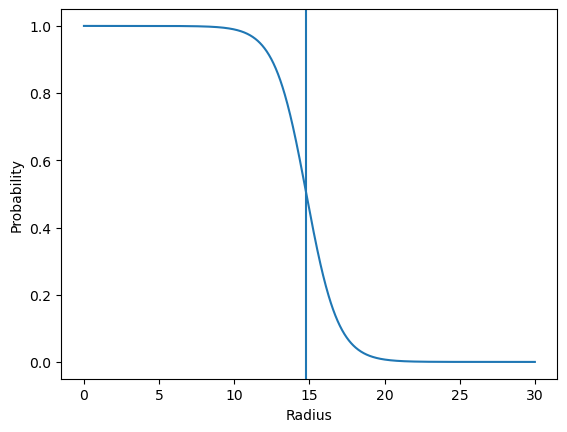

In [12]:
# 5. Optional: Visualization

plt.plot(X_new, y_proba_benign)
plt.axvline(x = decision_boundary)

plt.xlabel("Radius")
plt.ylabel("Probability")
plt.show()

## Task 3: Final Reflection
1. In the medical diagnosis task, why is it more useful to provide a **probability** (e.g., 55% chance of being malignant) rather than just a hard label (Malignant/Benign)?

**Answer:**


In medical diagnosis, such tools are not used to make final decision but used to give the medical professionals a starting point, hence it cannot be as simple as a hard label when the chances of it being one or another could be 51% and 49%. The uncertainty of a hard lable is too hight. A real medical decision cannot be made without seeing the % and professionals have to be informed in order to make an educated decision afterward.

## 🏆 Optional Challenge Task: Evaluating Model Performance (15 Minutes)
**Goal:** It's not enough to just "predict"; we need to know how many errors the model makes.

1. **Predictions:** Use your trained `log_reg` model to predict the classes for the entire **Test Set** (`X_test`).
2. **Confusion Matrix:** Use `sklearn.metrics.confusion_matrix` to create a matrix of the results.
3. **Visualization:** Use `ConfusionMatrixDisplay` to plot the matrix.
4. **Analysis:**
    * How many **False Positives** did the model produce? (Malignant tumors incorrectly labeled as Benign).
    * How many **False Negatives** did it produce? (Benign tumors incorrectly labeled as Malignant).

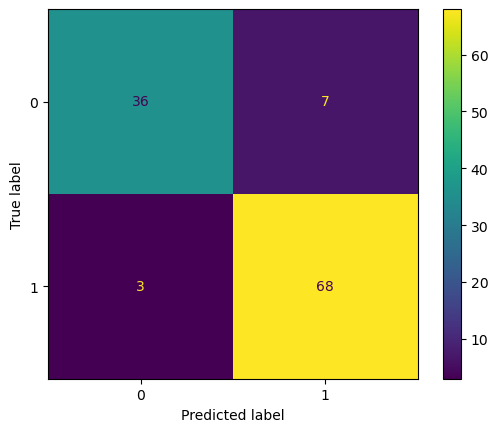

Malignant tumors missed (False Positives): 7
Benign tumors mislabeled (False Negatives): 3


In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions

y_pred = model2.predict(X_test2)

# Plot confusion matrix

ConfusionMatrixDisplay.from_predictions(y_test2, y_pred)
plt.show()

# Analysis

cm = confusion_matrix(y_test2, y_pred)

print(f"Malignant tumors missed (False Positives): {cm[0,1]}")
print(f"Benign tumors mislabeled (False Negatives): {cm[1,0]}")

**Why this is valuable:**
In a medical context, a False Positive (missing a malignant tumor) is much more dangerous than a False Negative (a false alarm). This is a great closing discussion about why we might adjust the Decision Boundary (e.g., moving it from 0.5 to 0.3) to be more "cautious" and catch more cancers, even if it creates more false alarms.